<a href="https://colab.research.google.com/github/remziicnnn/cifar10-cnn-image-classification/blob/main/g%C3%B6r%C3%BCnt%C3%BC_i%C5%9Fleme_proje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GÖRÜNTÜ İŞLEME DERSİ PROJE

**Remzican Sokur**  


**Dersin Öğretim Elemanı:......**

# 1. Problem Tanımı
**Proje Amacı:**

Bu proje, CIFAR-10 veri setini kullanarak bir görüntü sınıflandırma problemi çözmeyi amaçlamaktadır. CIFAR-10, 10 farklı sınıfa ait 60.000 renkli görüntüden oluşur ve her sınıf 6.000 görüntü içerir. Sınıflar, hava aracı, otomobil, kuş, kedi, geyik, köpek, kurbağa, at, gemi ve kamyondan oluşur.

**Veri Kümesi Tanımı:**

CIFAR-10 veri kümesi, her biri 32x32 piksel boyutunda olan 60.000 adet renkli görüntü içerir. Eğitim seti 50.000 görüntüden oluşur ve test setinde 10.000 görüntü yer alır.

**Hedef:**

Hedefimiz, bu verilerle bir sınıflandırma modeli kurarak her bir görüntüyü doğru sınıfa atamak.

# 2. Veri Hazırlama ve Görüntü Ön İşleme

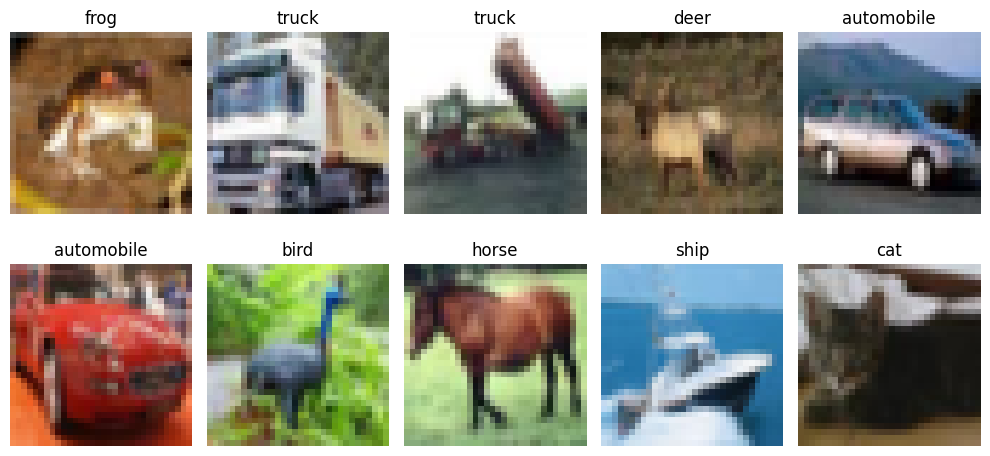

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# CIFAR-10 veri kümesini yükle
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

# Veriyi normalize et (0-255 arası değerler 0-1 arasına çekilir)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Etiketleri one-hot encoding yap
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Görüntülerin ilk 10'unu göster
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()


# 3. Öznitelik Çıkarımı

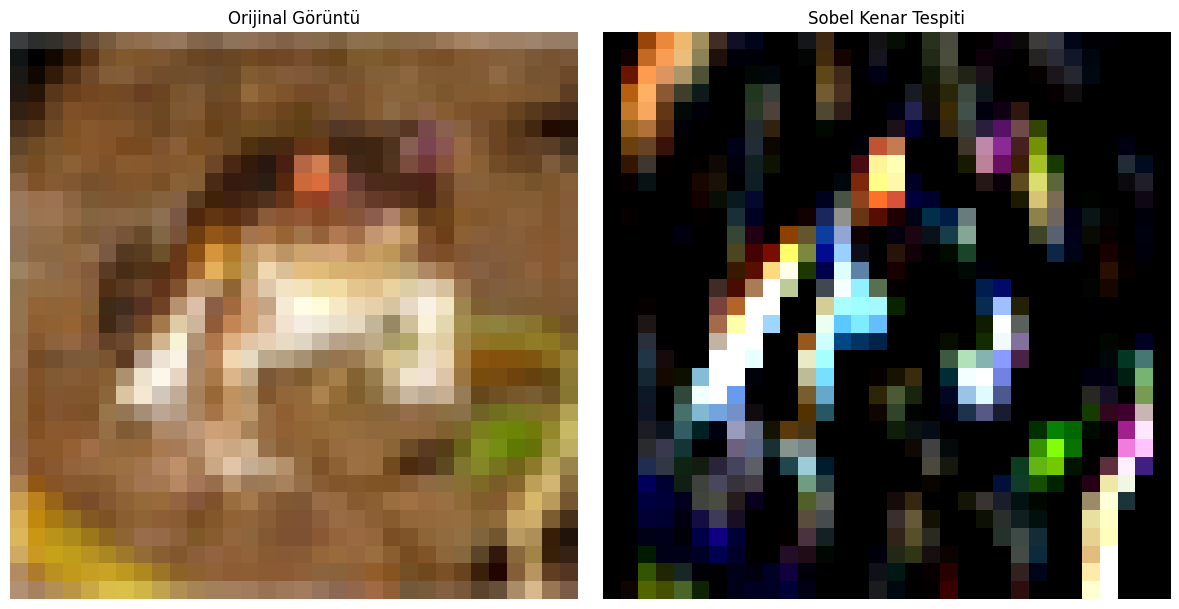

In [ ]:
import cv2

# Kenar tespiti (Sobel filtresi)
sobel_edges = cv2.Sobel(X_train[0], cv2.CV_64F, 1, 0, ksize=3)

# Görüntüyü görselleştir
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(X_train[0])
plt.title("Orijinal Görüntü")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(sobel_edges, cmap='gray')
plt.title("Sobel Kenar Tespiti")
plt.axis('off')
plt.tight_layout()
plt.show()


# 4. Modelleme
Bu adımda, görüntü sınıflandırma için Convolutional Neural Network (CNN) ve K-Nearest Neighbors (KNN) gibi iki farklı model oluşturulacak ve karşılaştırılacaktır.

**CNN Modeli:**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# CNN modelini oluştur
cnn_model = Sequential()
cnn_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=X_train.shape[1:]))
cnn_model.add(MaxPooling2D((2, 2)))
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(MaxPooling2D((2, 2)))
cnn_model.add(Dropout(0.3))

cnn_model.add(Flatten())
cnn_model.add(Dense(128, activation='relu'))
cnn_model.add(Dropout(0.4))
cnn_model.add(Dense(10, activation='softmax'))

# Modeli derle
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Modeli eğit
cnn_history = cnn_model.fit(
    X_train, y_train_cat,
    epochs=10,
    validation_data=(X_test, y_test_cat),
    batch_size=64
)

# Modelin test doğruluğunu yazdır
test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test_cat)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")



/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 84ms/step - accuracy: 0.3011 - loss: 1.8876 - val_accuracy: 0.5228 - val_loss: 1.3610
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 81ms/step - accuracy: 0.4940 - loss: 1.4149 - val_accuracy: 0.5909 - val_loss: 1.1837
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 83ms/step - accuracy: 0.5498 - loss: 1.2593 - val_accuracy: 0.6265 - val_loss: 1.0743
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 64s 82ms/step - accuracy: 0.5869 - loss: 1.1661 - val_accuracy: 0.6491 - val_loss: 1.0079
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 80ms/step - accuracy: 0.6133 - loss: 1.0972 - val_accuracy: 0.6611 - val_loss: 0.9737
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 84s 82ms/step - accuracy: 0.6281 - loss: 1.0589 - val_accuracy: 0.6720 - val_loss: 0.9325
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 81ms/step - accuracy: 0.6433 - loss: 1.0216 - val_accuracy: 0.6755 - val_loss: 0.9346
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 79ms/step - accuracy: 0.6553 - loss: 0.9866 - 

**KNN Modeli:**

In [ ]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# KNN modelini oluştur
knn_model = KNeighborsClassifier(n_neighbors=3)
X_train_flattened = X_train.reshape(X_train.shape[0], -1)  # Görüntüleri düzleştir
X_test_flattened = X_test.reshape(X_test.shape[0], -1)

# Modeli eğit
knn_model.fit(X_train_flattened, y_train.flatten())

# KNN modeli ile tahmin yap
knn_pred = knn_model.predict(X_test_flattened)

# KNN doğruluğunu hesapla
knn_accuracy = accuracy_score(y_test.flatten(), knn_pred)
print(f"KNN Accuracy: {knn_accuracy}")


KNN Accuracy: 0.3303


# 5. Performans Değerlendirmesi

**CNN Performans Değerlendirmesi:**

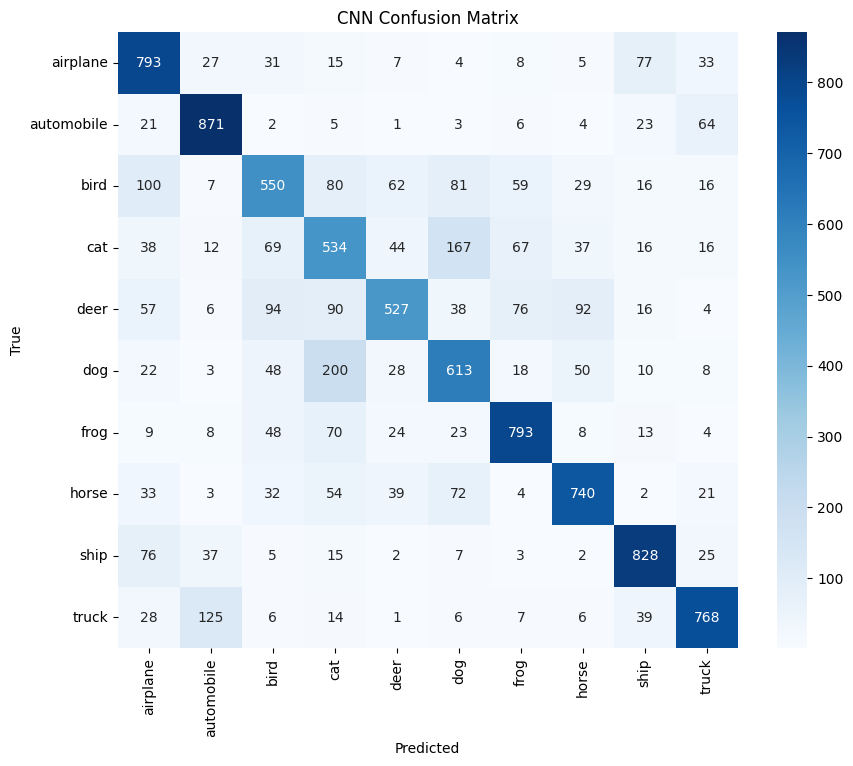

              precision    recall  f1-score   support

    airplane       0.67      0.79      0.73      1000
  automobile       0.79      0.87      0.83      1000
        bird       0.62      0.55      0.58      1000
         cat       0.50      0.53      0.51      1000
        deer       0.72      0.53      0.61      1000
         dog       0.60      0.61      0.61      1000
        frog       0.76      0.79      0.78      1000
       horse       0.76      0.74      0.75      1000
        ship       0.80      0.83      0.81      1000
       truck       0.80      0.77      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

# Confusion matrix
cm = confusion_matrix(y_test.flatten(), cnn_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('CNN Confusion Matrix')
plt.show()
# Sınıflandırma raporu
print(classification_report(y_test.flatten(), cnn_pred_classes, target_names=class_names))

**KNN Performans Değerlendirmesi:**

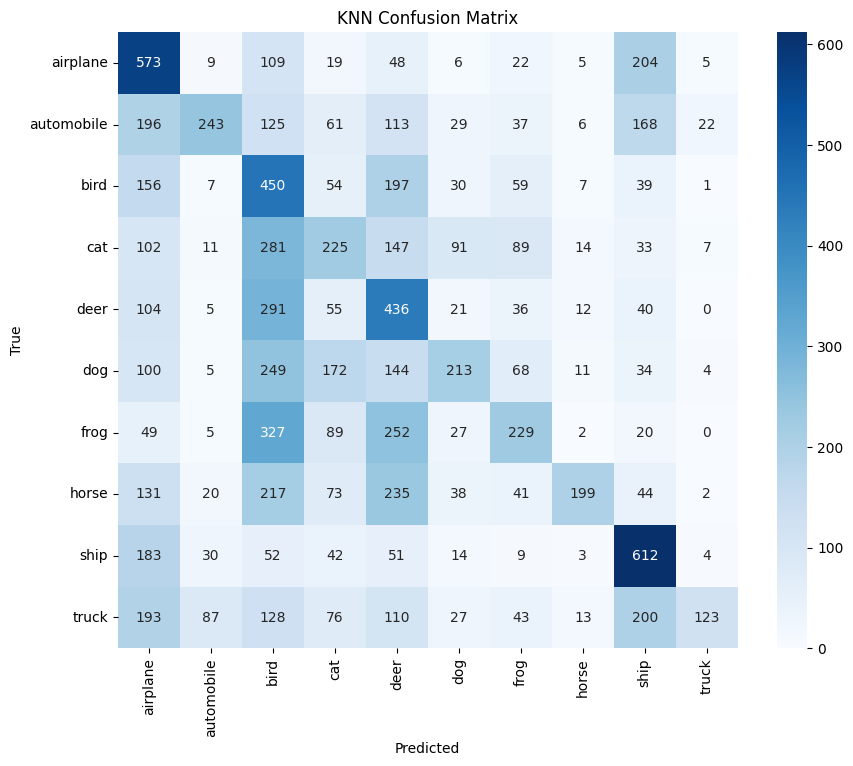

              precision    recall  f1-score   support

    airplane       0.32      0.57      0.41      1000
  automobile       0.58      0.24      0.34      1000
        bird       0.20      0.45      0.28      1000
         cat       0.26      0.23      0.24      1000
        deer       0.25      0.44      0.32      1000
         dog       0.43      0.21      0.28      1000
        frog       0.36      0.23      0.28      1000
       horse       0.73      0.20      0.31      1000
        ship       0.44      0.61      0.51      1000
       truck       0.73      0.12      0.21      1000

    accuracy                           0.33     10000
   macro avg       0.43      0.33      0.32     10000
weighted avg       0.43      0.33      0.32     10000



In [ ]:
# KNN Confusion Matrix ve Classification Report
knn_cm = confusion_matrix(y_test.flatten(), knn_pred)
plt.figure(figsize=(10,8))
sns.heatmap(knn_cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('KNN Confusion Matrix')
plt.show()

print(classification_report(y_test.flatten(), knn_pred, target_names=class_names))


# 6. Sonuç ve Yorumlar
Bu aşamada, her iki modelin performansını görsel olarak değerlendireceğiz. CNN modeli genellikle daha iyi sonuçlar verebilir çünkü konvolüsyonel katmanlar, görüntülerdeki özellikleri daha etkili şekilde öğrenebilir. KNN modeli ise basit bir algoritma olmasına rağmen düşük performans gösterebilir.

**Görsel Örnekler:**
Doğru ve yanlış sınıflandırılan örneklerin görselleştirilmesi:

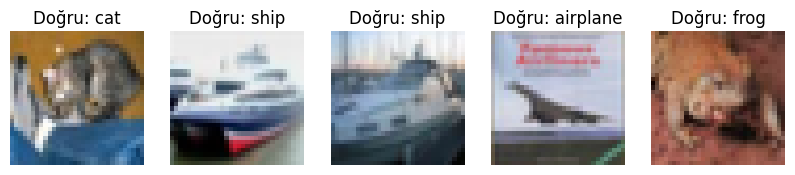

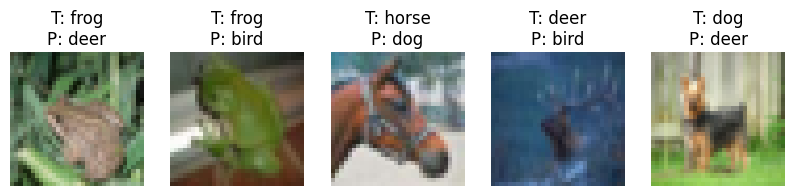

In [ ]:
# Doğru sınıflandırılan görüntüler
correct = np.where(cnn_pred_classes == y_test.flatten())[0]
plt.figure(figsize=(10,5))
for i, idx in enumerate(correct[:5]):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[idx])
    plt.title(f"Doğru: {class_names[y_test[idx][0]]}")
    plt.axis('off')
plt.show()

# Yanlış sınıflandırılan görüntüler
incorrect = np.where(cnn_pred_classes != y_test.flatten())[0]
plt.figure(figsize=(10,5))
for i, idx in enumerate(incorrect[:5]):
    plt.subplot(1,5,i+1)
    plt.imshow(X_test[idx])
    plt.title(f"T: {class_names[y_test[idx][0]]}\nP: {class_names[cnn_pred_classes[idx]]}")
    plt.axis('off')
plt.show()


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)